# **Decision Trees**

## **1. Preprocessing**
   - 1.1 Importing packages and data.
   - 1.2 Data Exploration: Check feature descriptions, missing values, odd characters, and imbalance in the dataset. Visualizing the distribution of features, and correlation analysis.

## **2. Transformations**
   - 2.1 Handle missing values, odd characters, and split the data. Apply any other transformations that you might consider necessary (e.g. OHE, Scaling, Imputation).

## **3. Basic Decision Tree Models**
   - 3.1 Train and evaluate a Simple Decision Tree using either Gini or Entropy.
   - 3.2 Visualise the tree.
   - 3.3 Train and evaluate a Simple Decision Tree using both `max_depth` and `min_samples_leaf`.
   - 3.4 Visualise the tree.
   - 3.5 Compare performance.

## **4. Ensemble Methods and Their Comparison**
   - 4.1 Train and evaluate a Random Forest.
   - 4.2 Train and evaluate a Simple Decision Tree using both `max_depth` and `min_samples_leaf`.
   - 4.3 Compare performance: Compare Random Forest against the simple Decision Tree.

# **Activity**

* You are required to implement a classification tree algorithm to solve a bank churn scenario.

* Follow the steps provided above in order to solve this problem.

* You are provided with all the necessary packages and helper function (if needed) to complete the exercise.


# 1.Pre-processing
### 1.1 Importing Packages and data



In [40]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Function to evaluate the model
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    print("ROC Score:", roc_auc_score(y_test, predictions))
    print("Accuracy Score", accuracy_score(y_test, predictions))

np.random.seed(0)

# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/C2_W5_Datasets/bank_churn_data_raw.csv", index_col=0)

feature_names = df.columns.tolist()
print(feature_names)

print(df.shape, '\n')
print(df.head(),'\n')
df.info()

['CreditScore', 'Location', 'Male', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
(5034, 11) 

  CreditScore Location Male   Age Tenure    Balance NumOfProducts HasCrCard  \
0       585.0      1.0    ?  53.0    2.0        0.0           2.0       1.0   
1       606.0      1.0  1.0  24.0    2.0        0.0           1.0       0.0   
2       633.0      0.0  1.0  44.0    1.0   118907.6           1.0       1.0   
3       602.0      0.0  1.0  40.0    2.0  149961.99           2.0       NaN   
4       645.0      1.0  1.0  31.0    4.0  132351.29           1.0       1.0   

  IsActiveMember EstimatedSalary  Exited  
0            1.0        91830.75       0  
1            1.0             NaN       0  
2            0.0        47777.15       0  
3            1.0        82696.84       0  
4            0.0       151887.16       0   

<class 'pandas.core.frame.DataFrame'>
Index: 5034 entries, 0 to 5033
Data columns (total 11 columns):
 #   Colu

### 1.2 Data Exploration

* Check for: feature descriptions, missing values, data types, odd characters, and imbalance in the dataset.
* Visualise the distribution of features, and correlation analysis.


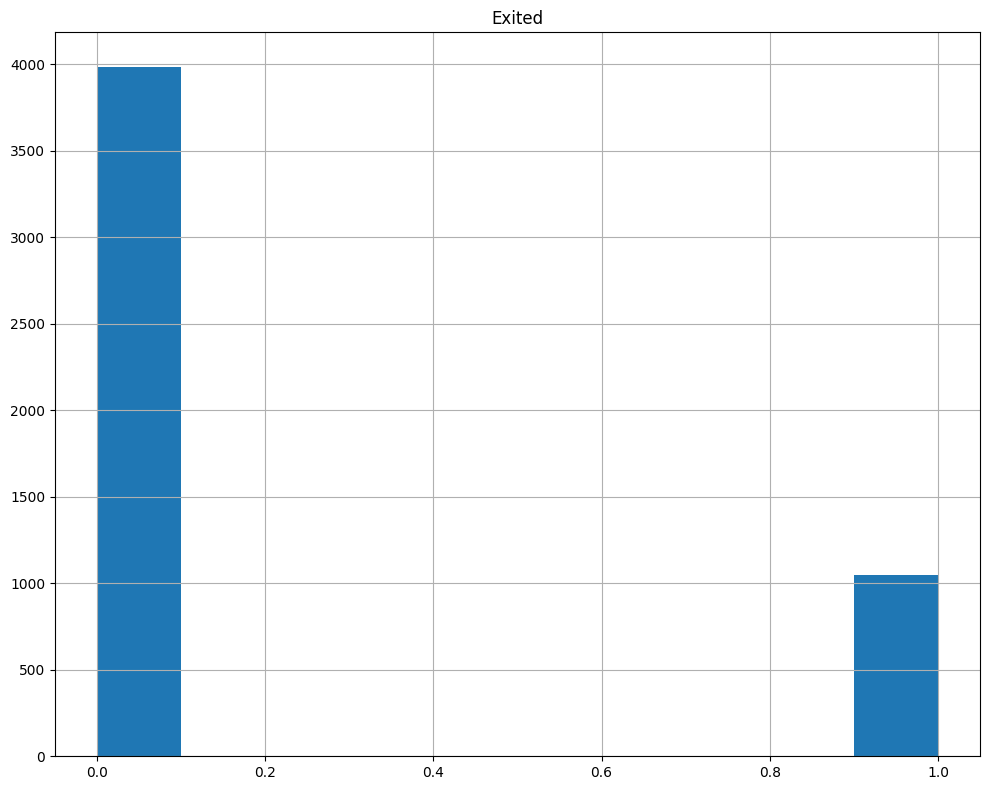

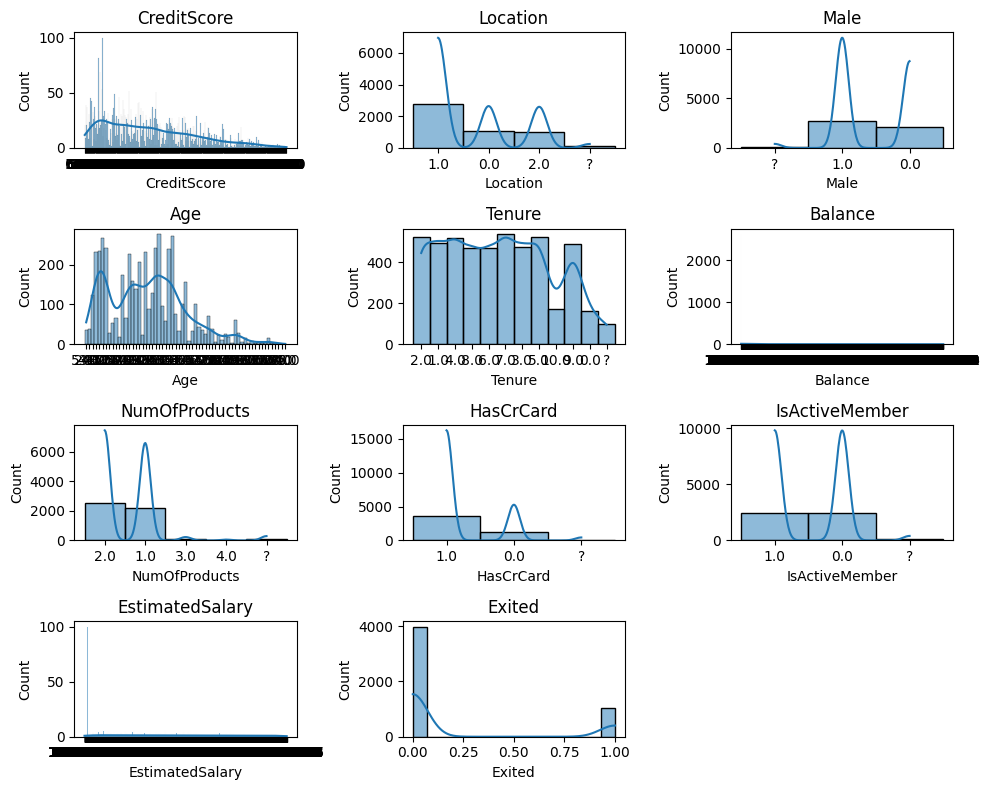

In [41]:
# Plot histograms for all features
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.tight_layout()


In [42]:
# Check for missing values, data types, odd characters, and imbalance in the dataset.
print("Null Values\n", df.isnull().sum(), '\n')

# Data types
print("Data types\n", df.dtypes, '\n')

# Odd characters
print(f" Odd characters\n", df.apply(lambda x: x.unique()), '\n')

# Imbalance
print(df['Exited'].value_counts(normalize=True), end="\n\n")

# Describe data
display(df.describe())

Null Values
 CreditScore         99
Location            97
Male                96
Age                100
Tenure             100
Balance             98
NumOfProducts       97
HasCrCard           94
IsActiveMember      98
EstimatedSalary     96
Exited               0
dtype: int64 

Data types
 CreditScore        object
Location           object
Male               object
Age                object
Tenure             object
Balance            object
NumOfProducts      object
HasCrCard          object
IsActiveMember     object
EstimatedSalary    object
Exited              int64
dtype: object 

 Odd characters
 CreditScore        [585.0, 606.0, 633.0, 602.0, 645.0, 558.0, 529...
Location                                     [1.0, 0.0, 2.0, ?, nan]
Male                                              [?, 1.0, 0.0, nan]
Age                [53.0, 24.0, 44.0, 40.0, 31.0, 37.0, 33.0, 57....
Tenure             [2.0, 1.0, 4.0, 8.0, 6.0, 7.0, 3.0, 5.0, 10.0,...
Balance            [0.0, 118907.6, 149961.9

,Exited
count,5034.000000
mean,0.208184
std,0.406050
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


# 2.Transformations
### 2.1 Handle missing values, odd characters, and split the data. Apply any other transformations that you might consider necessary (e.g. OHE, Scaling, Imputation).

* Remember the effects of applying any transformations pre/post splitting.



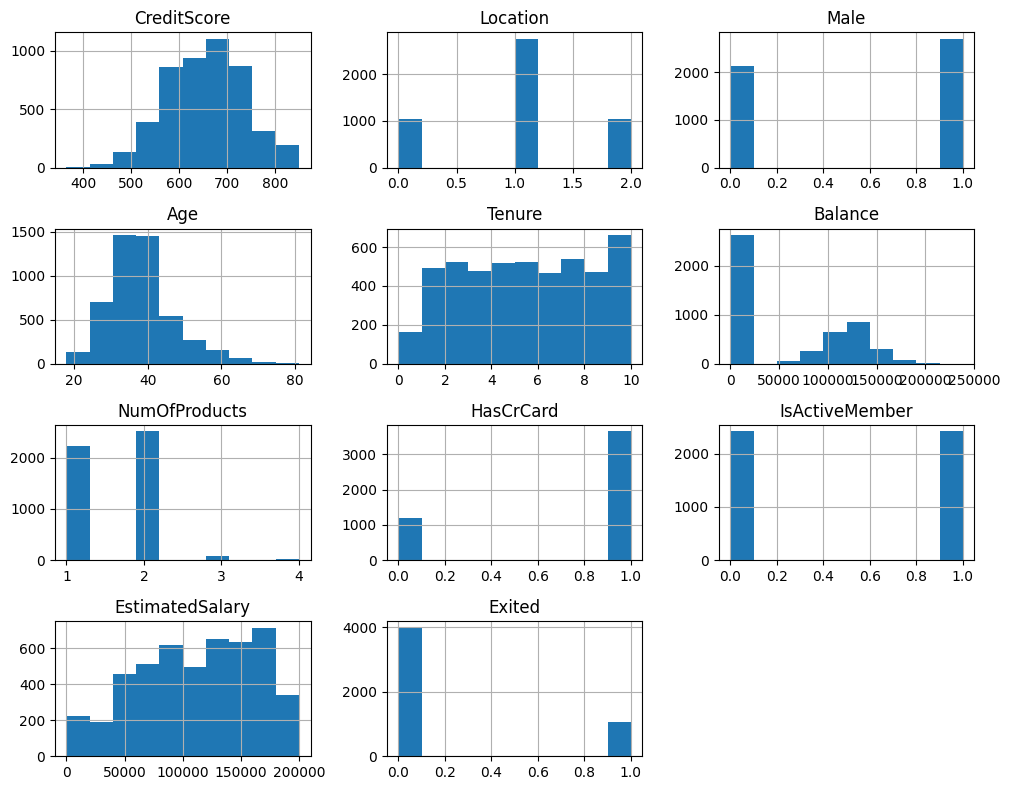

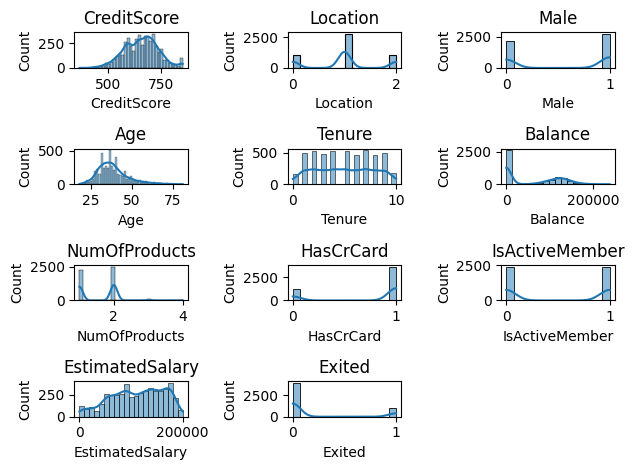

In [43]:
# Convert all object columns to numeric (float)

for column in df.select_dtypes(include=["object"]).columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")  # Converts non-numeric values to NaN

# If you specifically want integers, convert after ensuring valid values
df = df.astype({col: "float64" for col in df.columns if df[col].notna().all()})

# Plot histograms for all features
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

#plt.figure(figsize=(10,8))
for i, col in enumerate(df.columns):
    plt.subplot(4, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.tight_layout()


In [44]:
# replace NaN with mean values
# df.fillna(df.mean(), inplace=True)

# Cateforical columns
categorical_columns = ['Location', 'Male', 'IsActiveMember']
numerical_columns = df.columns.difference(categorical_columns)

print(categorical_columns)
print(numerical_columns)

# Impute numeric columns with median
num_imputer = SimpleImputer(strategy='median')
df[numerical_columns] = num_imputer.fit_transform(df[numerical_columns])

# Impute categorical columns with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = num_imputer.fit_transform(df[categorical_columns])

# Check for missing values
print(df.isnull().sum())

# Odd characters
# print(f" Odd characters\n", df.apply(lambda x: x.unique()), '\n')
# print(f"Nulls in data: {df.isnull().sum()} \n")

['Location', 'Male', 'IsActiveMember']
Index(['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Exited',
       'HasCrCard', 'NumOfProducts', 'Tenure'],
      dtype='object')
CreditScore        0
Location           0
Male               0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [45]:
display(df.describe())

,CreditScore,Location,Male,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,5034.000000,5034.000000,5034.000000,5034.000000,5034.00000,5034.000000,5034.000000,5034.000000,5034.000000,5034.000000,5034.000000
mean,656.062376,0.996424,0.576679,38.174811,4.98967,53467.854356,1.581248,0.764402,0.519865,111942.804998,0.208184
std,78.558299,0.642853,0.494134,8.834642,2.75034,62647.979698,0.546155,0.424414,0.499655,49111.559972,0.406050
min,365.000000,0.000000,0.000000,18.000000,0.00000,0.000000,1.000000,0.000000,0.000000,106.670000,0.000000
25%,598.000000,1.000000,0.000000,32.000000,3.00000,0.000000,1.000000,1.000000,0.000000,74850.355000,0.000000
50%,659.000000,1.000000,1.000000,37.000000,5.00000,0.000000,2.000000,1.000000,1.000000,115933.755000,0.000000
75%,708.000000,1.000000,1.000000,42.000000,7.00000,118667.627500,2.000000,1.000000,1.000000,152828.432500,0.000000
max,850.000000,2.000000,1.000000,81.000000,10.00000,238387.560000,4.000000,1.000000,1.000000,199953.330000,1.000000


In [46]:
# Checking for imbalance
print(df['Exited'].value_counts(normalize=True), end='\n')

exit_class = ["Customer exited" if i==1.0 else "Customer stayed" for i in df['Exited']]
df['Exited_label'] = exit_class

print(df['Exited_label'].value_counts(normalize=True), end='\n')

Exited
0.0    0.791816
1.0    0.208184
Name: proportion, dtype: float64
Exited_label
Customer stayed    0.791816
Customer exited    0.208184
Name: proportion, dtype: float64


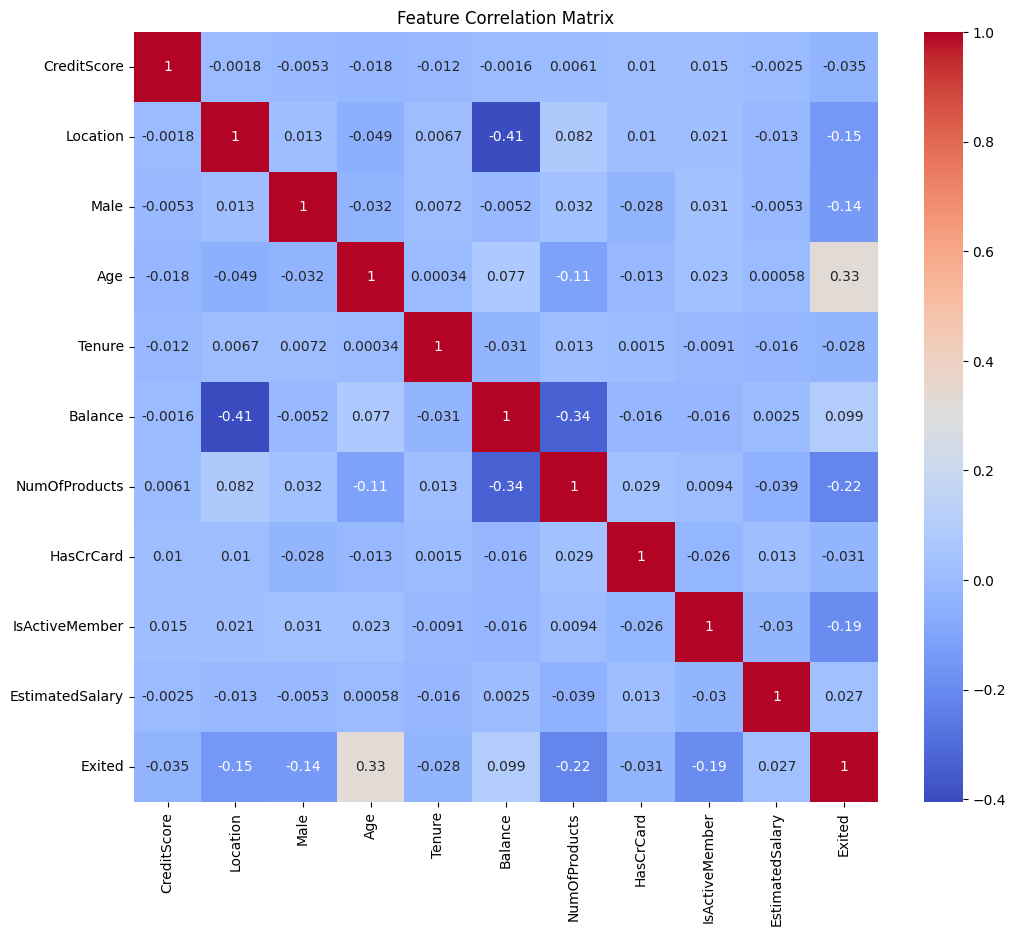

In [47]:
# Drop non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Correlation analysis
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

<Axes: >

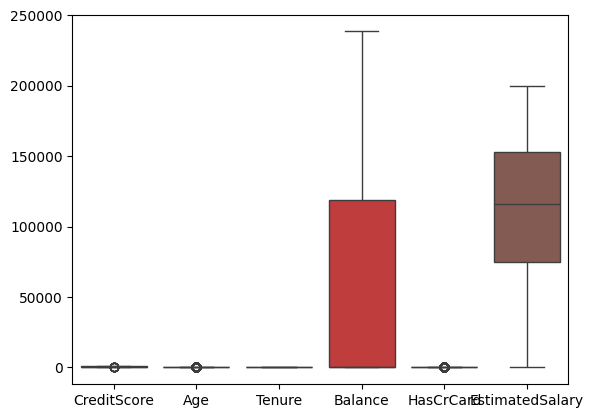

In [48]:
# Check for outliers
sns.boxplot(data=df[['CreditScore',  'Age', 'Tenure', 'Balance',  'HasCrCard',  'EstimatedSalary', ]])

# 'Male', 'NumOfProducts', 'Location', 'IsActiveMember',

#### Split the data

In [49]:
## Make a new copy of the columns used to make predictions
X = numeric_df.drop('Exited', axis=1).copy()
X.head()

y = numeric_df['Exited'].copy()
y.head()

## split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [50]:
### One Hot Encoding - Train
enc = OneHotEncoder(sparse_output=False,handle_unknown="ignore")
X_train_encoded = X_train.copy()
X_train_encoded.drop(categorical_columns,axis=1,inplace=True)

X_train_encoded_features = enc.fit_transform(X_train[categorical_columns])
encoded_feature_names = enc.get_feature_names_out(categorical_columns)

# Create the OHE dataset
X_train_encoded.loc[:,encoded_feature_names] = X_train_encoded_features
X_train_encoded.head()

### One Hot Encoding - Test
X_test_encoded = X_test.copy()
X_test_encoded.drop(categorical_columns,axis=1,inplace=True)
X_test_encoded_features = enc.transform(X_test[categorical_columns])

# Create the OHE dataset
X_test_encoded.loc[:,encoded_feature_names] = X_test_encoded_features
X_test_encoded.head()

# Make new column list
encoded_feature_names = list(X_train_encoded.columns)

print(encoded_feature_names)

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'EstimatedSalary', 'Location_0.0', 'Location_1.0', 'Location_2.0', 'Male_0.0', 'Male_1.0', 'IsActiveMember_0.0', 'IsActiveMember_1.0']


# 3.Basic Decision Tree Models
### 3.1 Train and evaluate a Simple Decision Tree using either Gini or Entropy.

* Remember to consider metrics based on whether the dataset is imbalanced or not.

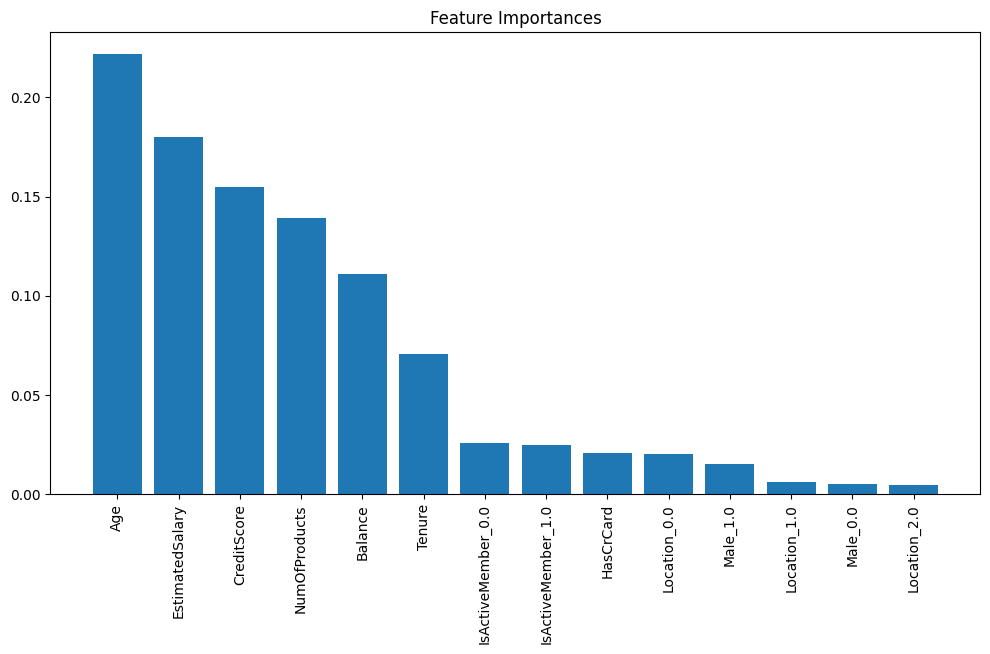

ROC Score: 0.6723558717380678
Accuracy Score 0.7743216412971542


In [52]:
# Building Decision Tree Model
tree_classifier = DecisionTreeClassifier(criterion='gini', random_state=0)
tree_classifier.fit(X_train_encoded, y_train)

# Model Evaluation
y_pred_gini = tree_classifier.predict(X_test_encoded)

# Visualize feature importances
importances = tree_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train_encoded.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_encoded.shape[1]), X_train_encoded.columns[indices], rotation=90)
plt.show()

# Evaluate the basic tree classifier
evaluate_model(tree_classifier, X_test_encoded, y_test)


### 3.2 Visualise the tree.


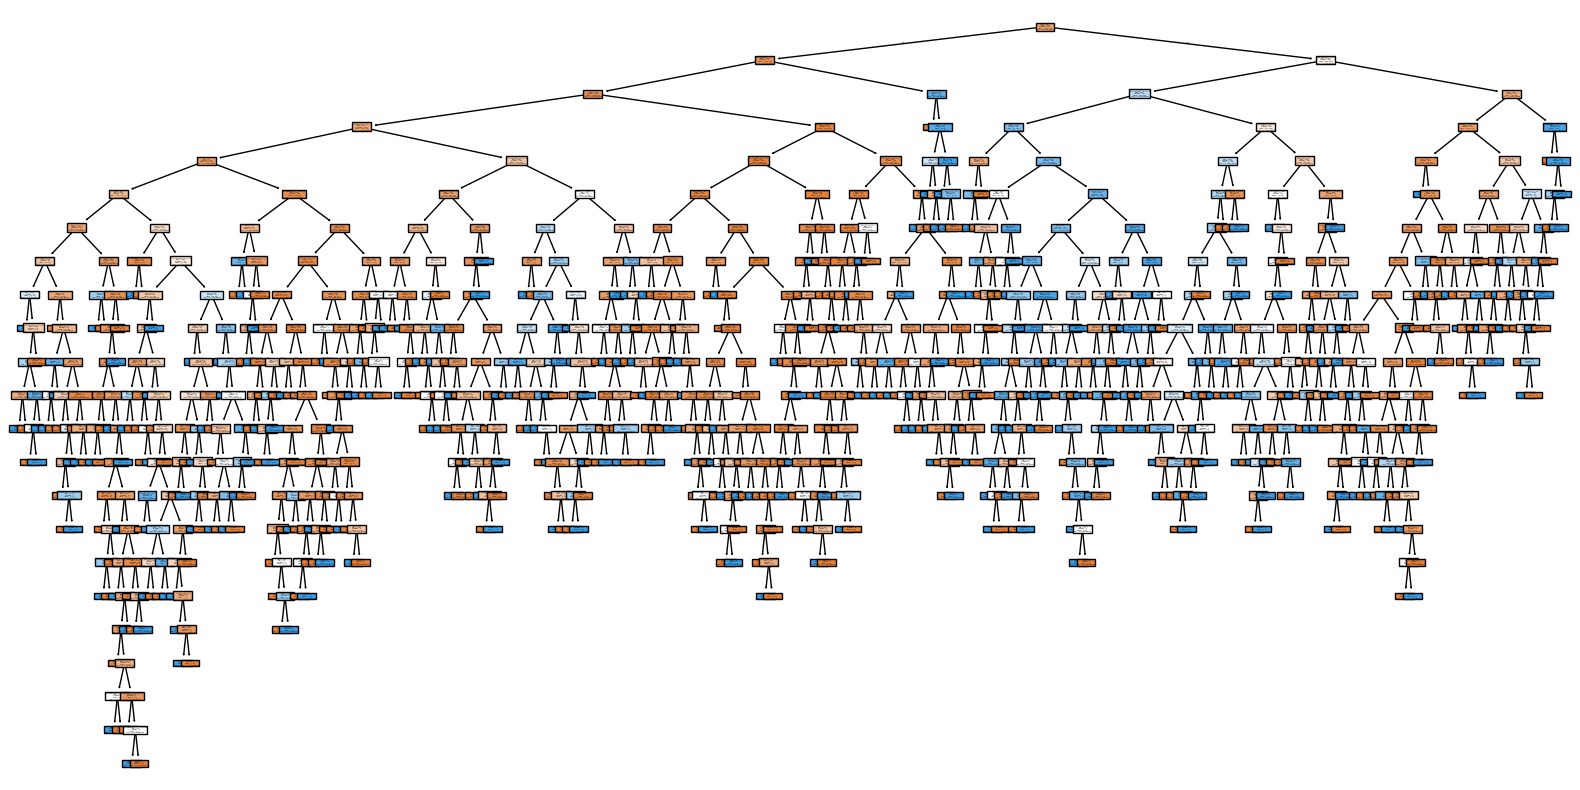

In [53]:
# Decision Tree Visualization
plt.figure(figsize=(20,10))
plot_tree(tree_classifier, feature_names=list(X_train_encoded.columns), class_names=exit_class, filled=True)
plt.show()

### 3.3 Train and evaluate a Simple Decision Tree using both `max_depth` and `min_samples_leaf`.


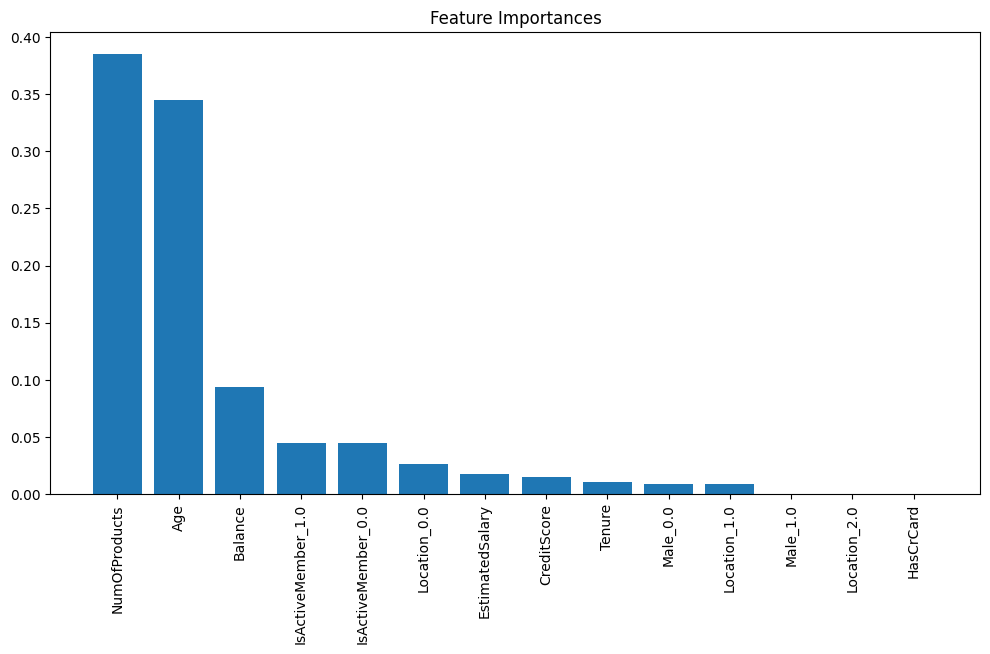

ROC Score: 0.7221949202783239
Accuracy Score 0.8438120450033091


In [60]:
# Configure your hyperparameters
max_depth = 5
min_samples_leaf = 10

# Building Decision Tree Model
tree_classifier_1 = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                           criterion='entropy', random_state=0)
tree_classifier_1.fit(X_train_encoded, y_train)

# Model Evaluation
y_pred_entropy = tree_classifier_1.predict(X_test_encoded)

# Visualize feature importances
importances = tree_classifier_1.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances")
plt.bar(range(X_train_encoded.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_encoded.shape[1]), X_train_encoded.columns[indices], rotation=90)
plt.show()

# Evaluate the basic tree classifier
evaluate_model(tree_classifier_1, X_test_encoded, y_test)

### 3.4 Visualise the tree


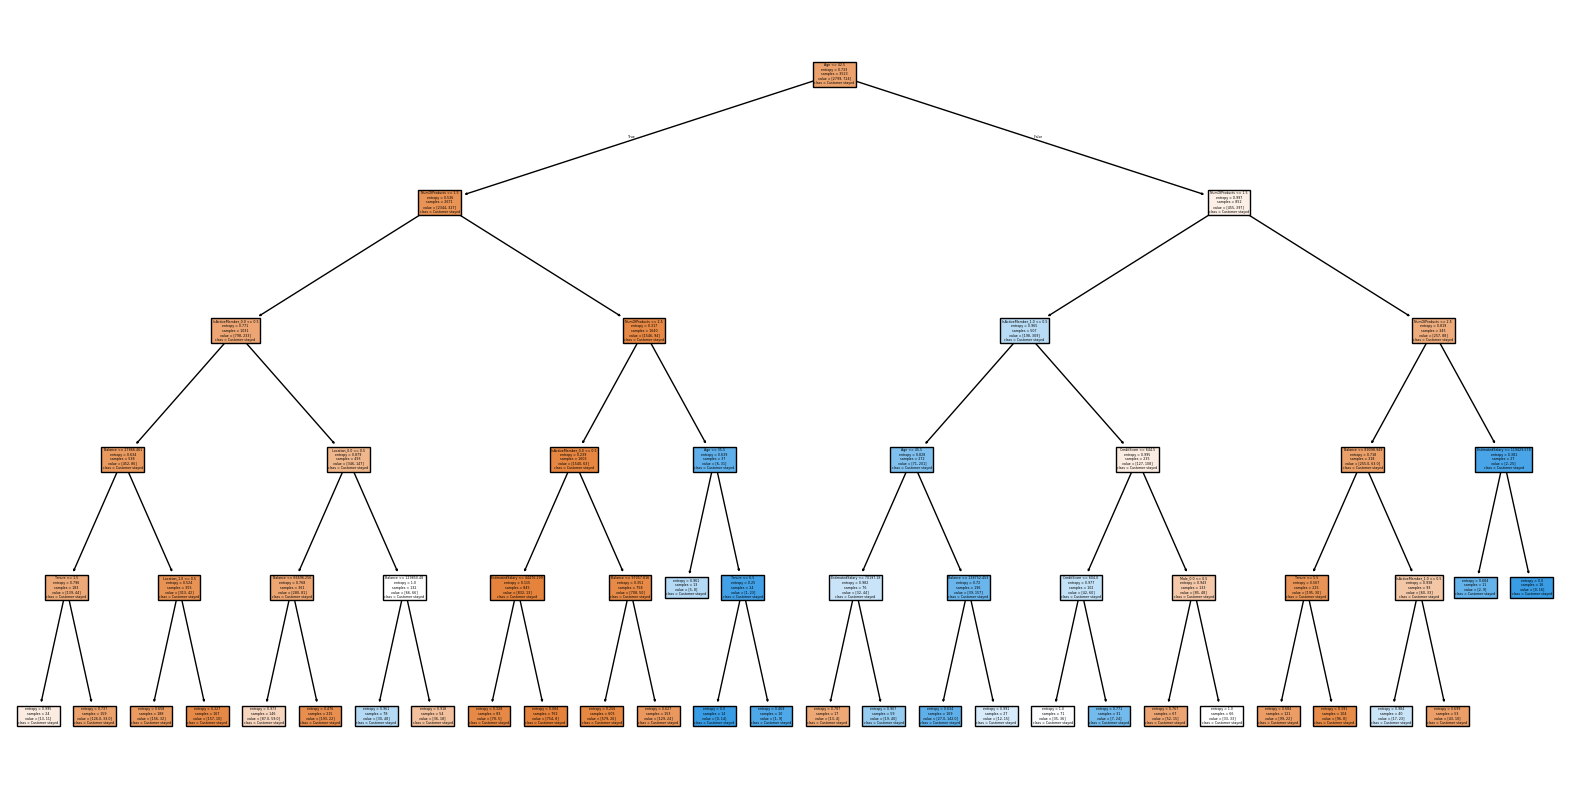

In [58]:
# Decision Tree Visualization
plt.figure(figsize=(20,10))
plot_tree(tree_classifier_1, feature_names=list(X_train_encoded.columns), class_names=exit_class, filled=True)
plt.show()

### 3.5 Compare performance

In [61]:
gini_accuracy = accuracy_score(y_test, y_pred_gini)
entropy_accuracy = accuracy_score(y_test, y_pred_entropy)

print(f"Accuracy using Gini Impurity: {gini_accuracy:.2f}")
print(f"Accuracy using Entropy: {entropy_accuracy:.2f}")

Accuracy using Gini Impurity: 0.84
Accuracy using Entropy: 0.84


# 4.Ensemble Methods and Their Comparison
### 4.1 Train and evaluate a Random Forest


In [69]:
random_forest = RandomForestClassifier(max_depth=7, min_samples_leaf=10, n_estimators=100, random_state=0)
random_forest.fit(X_train, y_train)
random_forest_pred = random_forest.predict(X_test)

### 4.2 Train and evaluate a Simple Decision Tree using both `max_depth` and `min_samples_leaf`


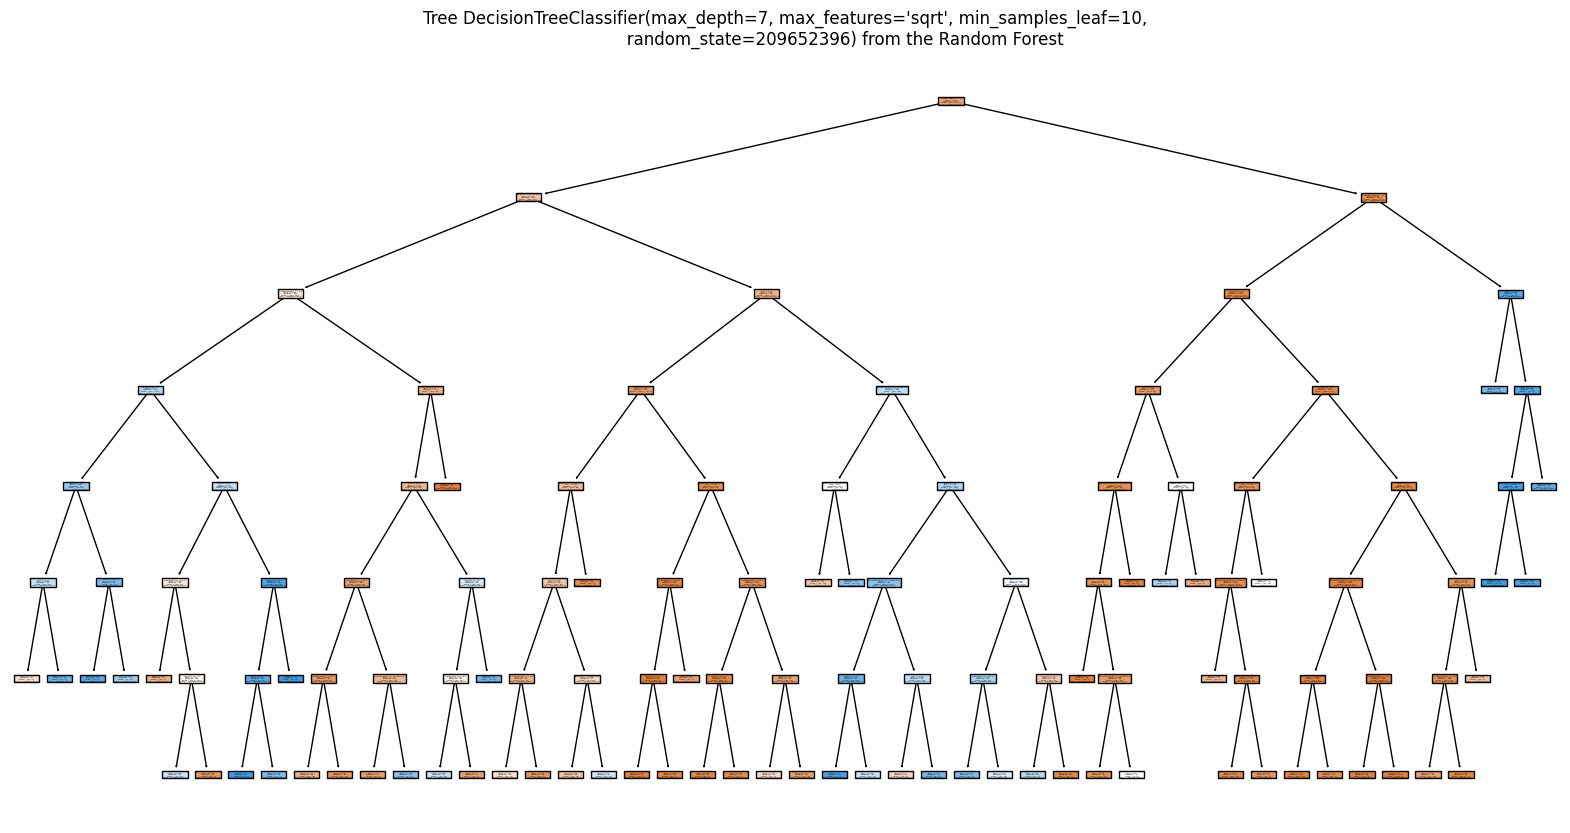

In [76]:
# Select a single tree from your trained Random Forest model
# Visualize the first three trees
#for i in range(3):
plt.figure(figsize=(20,10))
tree = random_forest.estimators_[0]
plot_tree(tree, filled=True, feature_names=list(X_train.columns), class_names=exit_class)
plt.title(f"Tree {tree} from the Random Forest")
plt.show()

### 4.3 Compare performance: Compare Random Forest against the simple Decision Tree

In [77]:
random_forest_acc = accuracy_score(y_test, random_forest_pred)
gini_accuracy = accuracy_score(y_test, y_pred_gini)
entropy_accuracy = accuracy_score(y_test, y_pred_entropy)

print(f"Accuracy using Gini Impurity: {gini_accuracy:.2f}")
print(f"Accuracy using Entropy: {entropy_accuracy:.2f}")
print(f"Accuracy using Random Forest: {random_forest_acc:.2f}")

Accuracy using Gini Impurity: 0.84
Accuracy using Entropy: 0.84
Accuracy using Random Forest: 0.85
